# EDA for patient

In [3]:
import pandas as pd

patients = pd.read_csv('./data/hosp/patients.csv/patients.csv')

patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [4]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subject_id         100 non-null    int64 
 1   gender             100 non-null    object
 2   anchor_age         100 non-null    int64 
 3   anchor_year        100 non-null    int64 
 4   anchor_year_group  100 non-null    object
 5   dod                31 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [5]:
# How many unique values for each column
patients.nunique()

subject_id           100
gender                 2
anchor_age            50
anchor_year           62
anchor_year_group      2
dod                   31
dtype: int64

In [6]:
# How many missing values
patients.isna().sum()

subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64

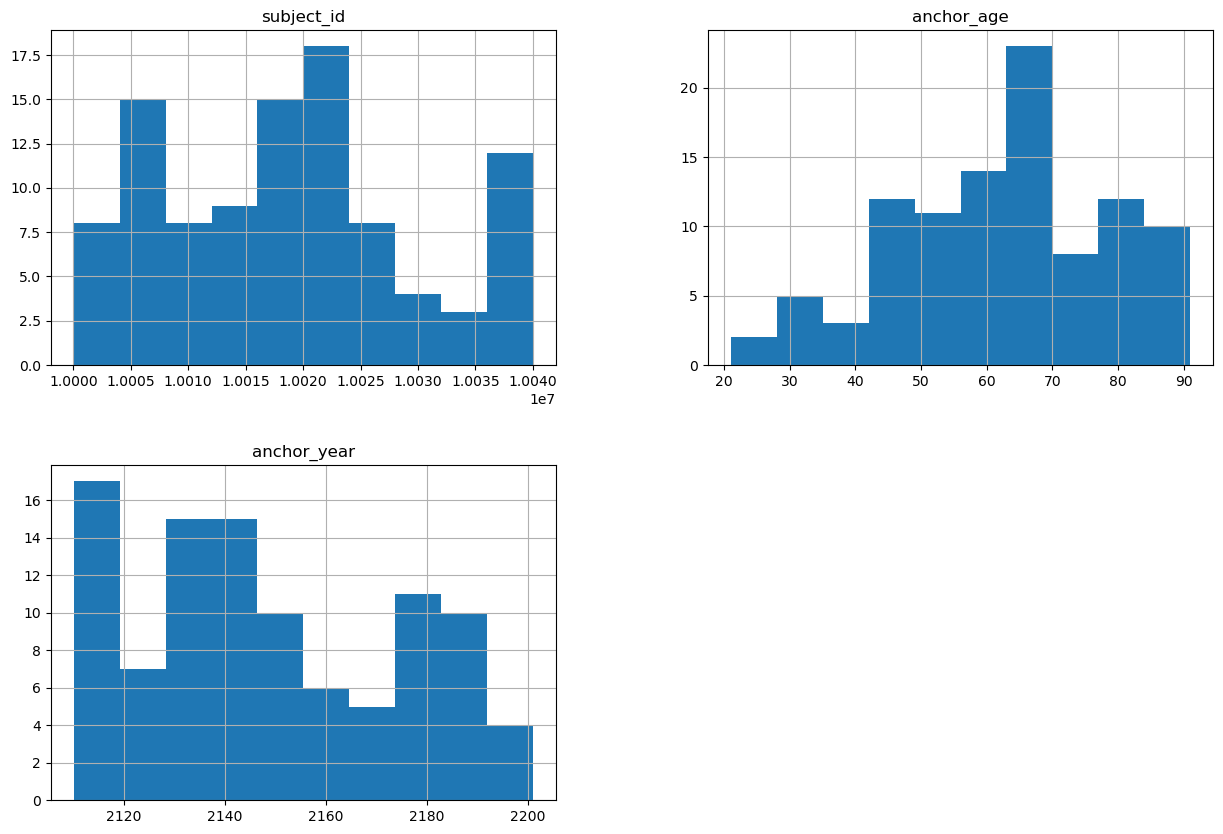

In [7]:
# EDA_patients
# the distribution of continous variables

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

patients.hist(figsize=(15,10))

plt.show()

In [8]:
patients.anchor_age.describe()

count    100.00000
mean      61.75000
std       16.16979
min       21.00000
25%       51.75000
50%       63.00000
75%       72.00000
max       91.00000
Name: anchor_age, dtype: float64

In [9]:
top_5_ages = patients['anchor_age'].nlargest(5)

print(top_5_ages)

9     91
23    91
83    91
18    89
41    88
Name: anchor_age, dtype: int64


c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


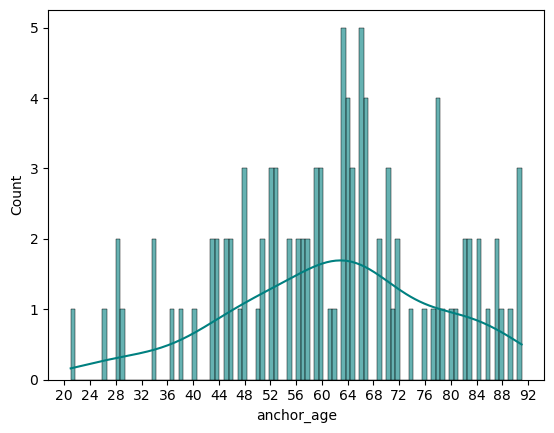

In [10]:
sns.histplot(data=patients, x='anchor_age', bins=100, kde=True, color='teal', alpha=0.6)
plt.xticks(np.arange(20, 93, 4));

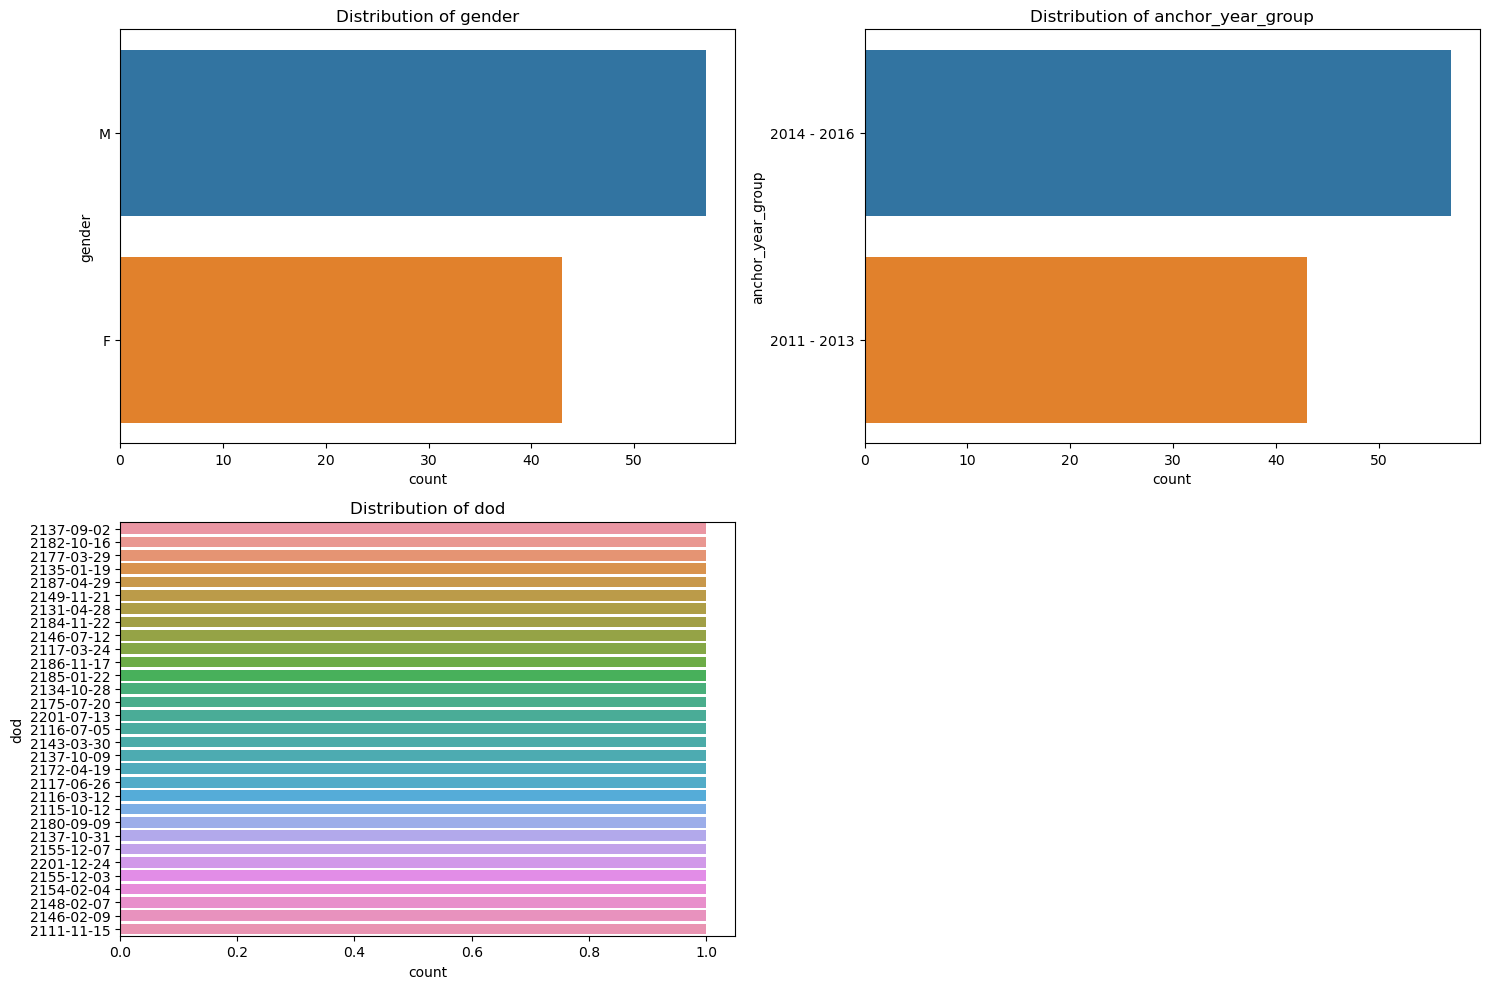

In [11]:
cat_cols = patients.select_dtypes(include=['object', 'category']).columns

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    #  sorted in order of frequency
    sns.countplot(data=patients, y=col, order=patients[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

In [12]:
for col in cat_cols :
    print(f"--- {col} ---")
    print(patients[col].value_counts(normalize=True) * 100) # as a percent
    print("\n")

--- gender ---
gender
M    57.0
F    43.0
Name: proportion, dtype: float64


--- anchor_year_group ---
anchor_year_group
2014 - 2016    57.0
2011 - 2013    43.0
Name: proportion, dtype: float64


--- dod ---
dod
2137-09-02    3.225806
2182-10-16    3.225806
2177-03-29    3.225806
2135-01-19    3.225806
2187-04-29    3.225806
2149-11-21    3.225806
2131-04-28    3.225806
2184-11-22    3.225806
2146-07-12    3.225806
2117-03-24    3.225806
2186-11-17    3.225806
2185-01-22    3.225806
2134-10-28    3.225806
2175-07-20    3.225806
2201-07-13    3.225806
2116-07-05    3.225806
2143-03-30    3.225806
2137-10-09    3.225806
2172-04-19    3.225806
2117-06-26    3.225806
2116-03-12    3.225806
2115-10-12    3.225806
2180-09-09    3.225806
2137-10-31    3.225806
2155-12-07    3.225806
2201-12-24    3.225806
2155-12-03    3.225806
2154-02-04    3.225806
2148-02-07    3.225806
2146-02-09    3.225806
2111-11-15    3.225806
Name: proportion, dtype: float64




# EDA for admissions

In [13]:
admissions = pd.read_csv('./data/hosp/admissions.csv/admissions.csv')

admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [14]:
admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   subject_id            275 non-null    int64 
 1   hadm_id               275 non-null    int64 
 2   admittime             275 non-null    object
 3   dischtime             275 non-null    object
 4   deathtime             15 non-null     object
 5   admission_type        275 non-null    object
 6   admit_provider_id     275 non-null    object
 7   admission_location    275 non-null    object
 8   discharge_location    233 non-null    object
 9   insurance             275 non-null    object
 10  language              275 non-null    object
 11  marital_status        263 non-null    object
 12  race                  275 non-null    object
 13  edregtime             182 non-null    object
 14  edouttime             182 non-null    object
 15  hospital_expire_flag  275 non-null    in

In [15]:
admissions.nunique()

subject_id              100
hadm_id                 275
admittime               275
dischtime               275
deathtime                15
admission_type            9
admit_provider_id       170
admission_location       10
discharge_location       10
insurance                 3
language                  2
marital_status            4
race                     14
edregtime               181
edouttime               181
hospital_expire_flag      2
dtype: int64

In [16]:
admissions.isna().sum()

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
dtype: int64

In [17]:
# check missing answer in marital_status
unknown_values = ['UNKNOWN', 'MARITAL_STATUS UNKNOWN', '']
cond_null = admissions['marital_status'].isnull()
cond_unknown = admissions['marital_status'].isin(unknown_values)
missing_rows = admissions[cond_null | cond_unknown]
print(missing_rows[['subject_id', 'hadm_id', 'marital_status']].head(12))

     subject_id   hadm_id marital_status
3      10006053  22942076            NaN
11     10026354  24547356            NaN
23     10036156  28019404            NaN
24     10021312  25020332            NaN
25     10021312  28829452            NaN
41     10019172  24997044            NaN
42     10019172  21540783            NaN
60     10015272  27993466            NaN
61     10016810  20973395            NaN
68     10020944  29974575            NaN
90     10014078  25809882            NaN
124    10018501  28479513            NaN


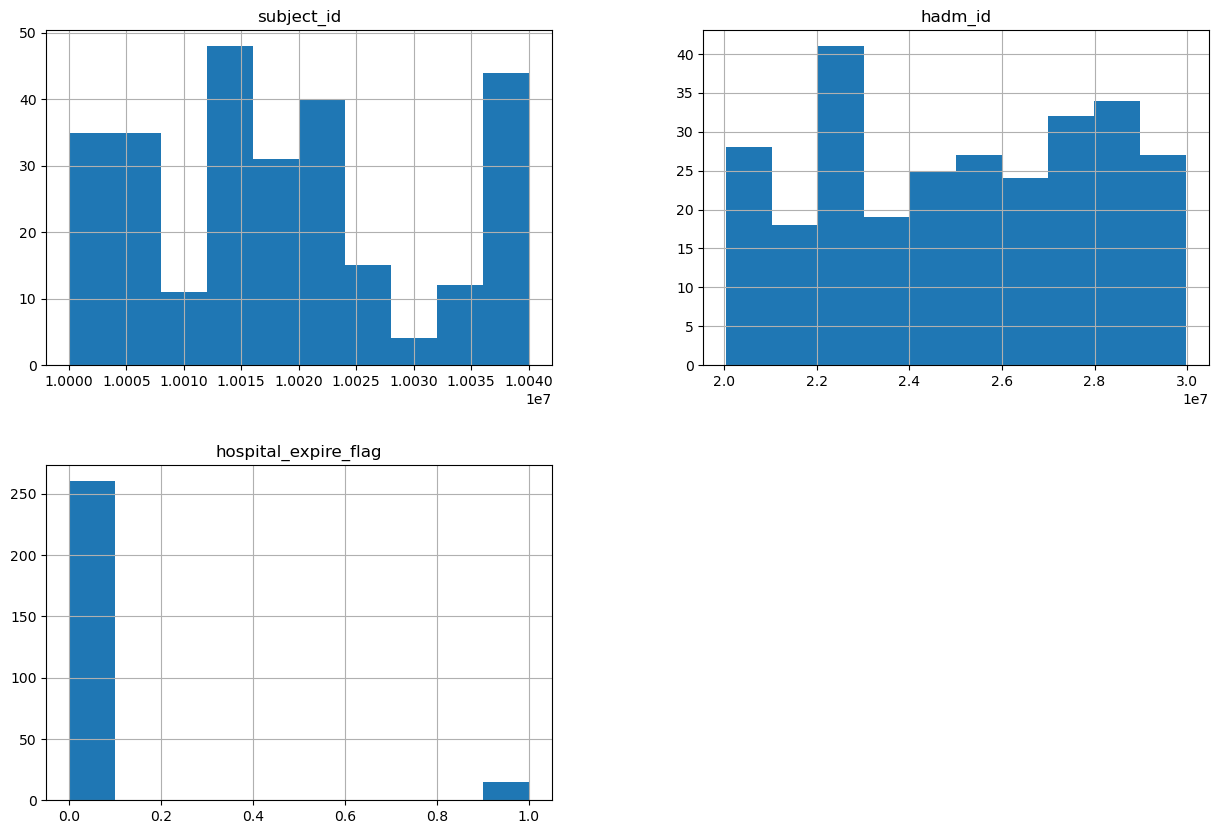

In [18]:
# EDA_admissions
# the distribution of continous variables

admissions.hist(figsize=(15,10))

plt.show()

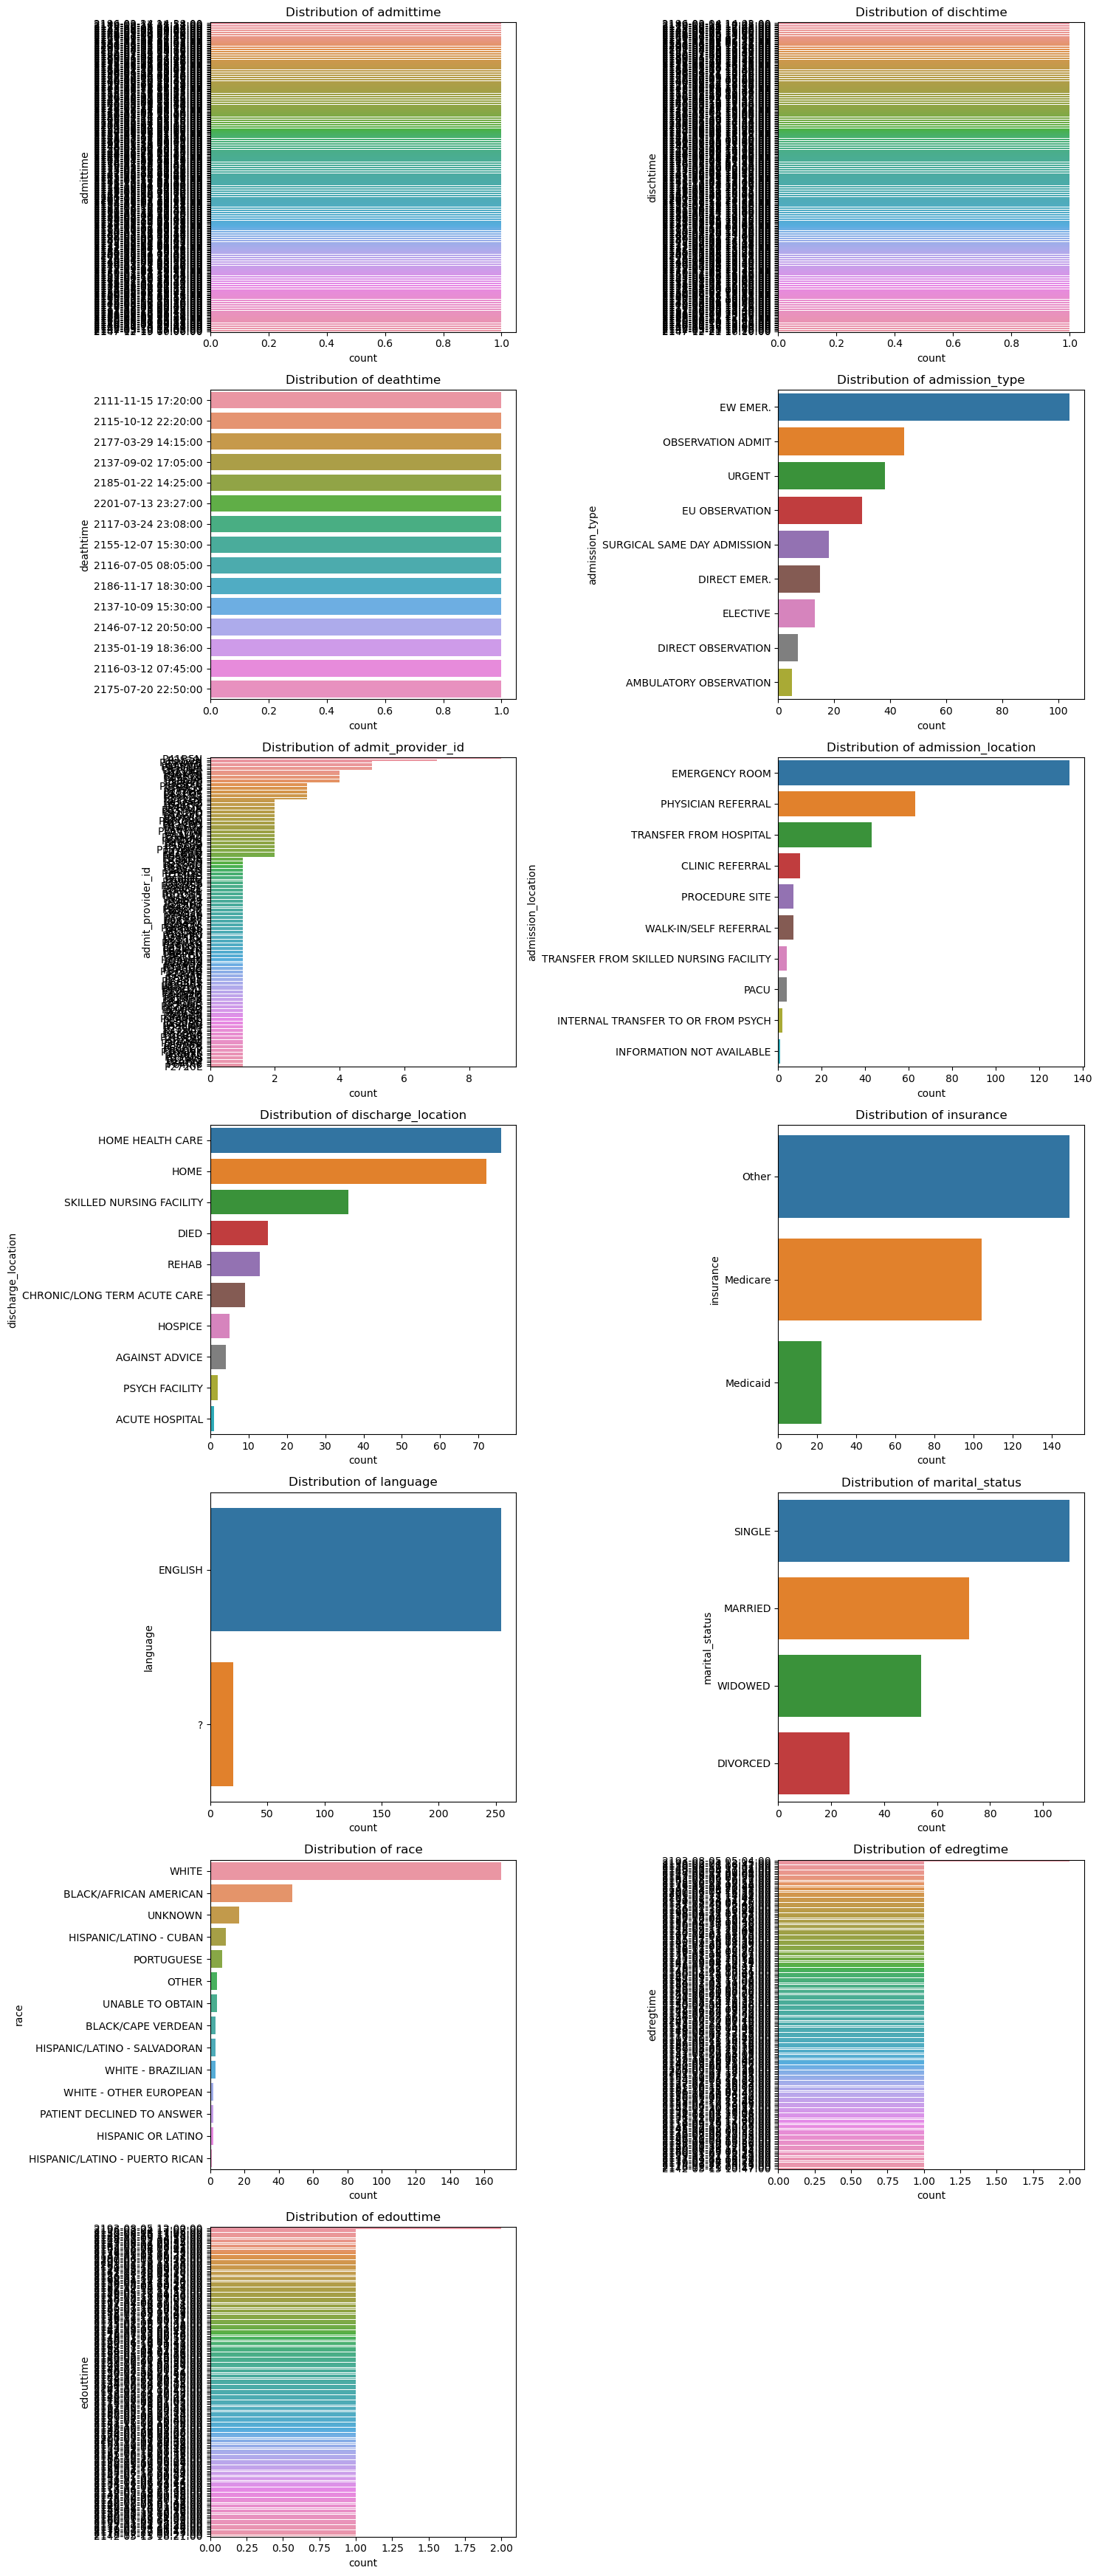

In [19]:
cat_cols = admissions.select_dtypes(include=['object', 'category']).columns

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    #  sorted in order of frequency
    sns.countplot(data=admissions, y=col, order=admissions[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

In [20]:
for col in cat_cols :
    print(f"--- {col} ---")
    print(admissions[col].value_counts(normalize=True) * 100) # as a percent
    print("\n")

--- admittime ---
admittime
2196-02-24 14:38:00    0.363636
2149-09-17 22:54:00    0.363636
2176-08-11 15:17:00    0.363636
2175-10-26 01:31:00    0.363636
2183-08-04 04:04:00    0.363636
                         ...   
2150-04-10 02:40:00    0.363636
2148-09-10 12:09:00    0.363636
2142-05-10 15:05:00    0.363636
2187-05-18 17:08:00    0.363636
2147-12-19 00:00:00    0.363636
Name: proportion, Length: 275, dtype: float64


--- dischtime ---
dischtime
2196-03-04 14:02:00    0.363636
2149-09-18 10:45:00    0.363636
2176-08-11 17:35:00    0.363636
2175-10-26 12:48:00    0.363636
2183-08-04 16:07:00    0.363636
                         ...   
2150-04-15 18:00:00    0.363636
2148-09-23 12:18:00    0.363636
2142-05-15 19:49:00    0.363636
2187-05-23 17:20:00    0.363636
2147-12-21 16:10:00    0.363636
Name: proportion, Length: 275, dtype: float64


--- deathtime ---
deathtime
2111-11-15 17:20:00    6.666667
2115-10-12 22:20:00    6.666667
2177-03-29 14:15:00    6.666667
2137-09-02 17:05:00 

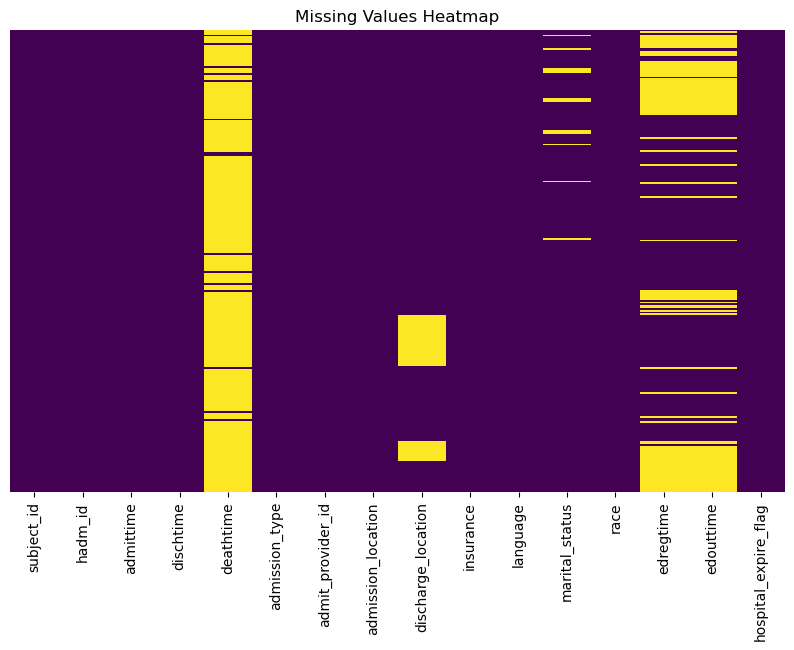

In [21]:
# checking missing data in admissions
plt.figure(figsize=(10, 6))
sns.heatmap(admissions.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

adjusting imbalanced variables

In [22]:
admissions_ver1 = admissions.copy()

In [23]:
others_list = ['ELECTIVE', 'DIRECT OBSERVATION', 'AMBULATORY OBSERVATION']

In [24]:
admissions_ver1['admission_type'] = admissions_ver1['admission_type'].replace(others_list, 'OTHERS')

In [25]:
print(admissions_ver1['admission_type'].value_counts())

admission_type
EW EMER.                       104
OBSERVATION ADMIT               45
URGENT                          38
EU OBSERVATION                  30
OTHERS                          25
SURGICAL SAME DAY ADMISSION     18
DIRECT EMER.                    15
Name: count, dtype: int64


In [26]:
unique_types = admissions_ver1['admission_type'].unique()
print(f"\n number of categories: {len(unique_types)}")
print(f"list of categories: {unique_types}")


 number of categories: 7
list of categories: ['URGENT' 'OTHERS' 'EW EMER.' 'DIRECT EMER.' 'EU OBSERVATION'
 'OBSERVATION ADMIT' 'SURGICAL SAME DAY ADMISSION']


In [27]:
others_list1 = ['HISPANIC/LATINO - CUBAN', 'PORTUGUESE', 'OTHER', 'BLACK/CAPE VERDEAN', 
    'HISPANIC/LATINO - SALVADORAN', 'WHITE - BRAZILIAN', 'WHITE - OTHER EUROPEAN', 
    'HISPANIC OR LATINO', 'HISPANIC/LATINO - PUERTO RICAN']
others_list2 = ['PATIENT DECLINED TO ANSWER', 'UNABLE TO OBTAIN']

In [28]:
admissions_ver1['race'] = admissions_ver1['race'].replace(others_list1, 'OTHER RACE')

In [29]:
admissions_ver1['race'] = admissions_ver1['race'].replace(others_list2, 'DECLINED OR UNABLE TO OBTAIN')

In [31]:
unique_types = admissions_ver1['race'].unique()
print(f"\nnumber of categories: {len(unique_types)}")
print(f"list of categories: {unique_types}")


number of categories: 5
list of categories: ['OTHER RACE' 'WHITE' 'UNKNOWN' 'BLACK/AFRICAN AMERICAN'
 'DECLINED OR UNABLE TO OBTAIN']


In [32]:
admissions_ver1.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,OTHER RACE,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,OTHER RACE,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [33]:
# Convert time information to Datetime
time_cols = ['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime']

for col in time_cols:
    admissions_ver1[f'{col}_dt'] = pd.to_datetime(admissions_ver1[col], errors='coerce')

print(admissions_ver1.dtypes)

subject_id                       int64
hadm_id                          int64
admittime                       object
dischtime                       object
deathtime                       object
admission_type                  object
admit_provider_id               object
admission_location              object
discharge_location              object
insurance                       object
language                        object
marital_status                  object
race                            object
edregtime                       object
edouttime                       object
hospital_expire_flag             int64
admittime_dt            datetime64[ns]
dischtime_dt            datetime64[ns]
deathtime_dt            datetime64[ns]
edregtime_dt            datetime64[ns]
edouttime_dt            datetime64[ns]
dtype: object


# EDA for diagnoses_icd

In [34]:
diagnoses = pd.read_csv(r'./data/hosp/diagnoses_icd.csv.gz')

In [35]:
diagnoses.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


In [36]:
diagnoses.info()
diagnoses.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4506 entries, 0 to 4505
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   subject_id   4506 non-null   int64 
 1   hadm_id      4506 non-null   int64 
 2   seq_num      4506 non-null   int64 
 3   icd_code     4506 non-null   object
 4   icd_version  4506 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 176.1+ KB


subject_id      100
hadm_id         275
seq_num          39
icd_code       1472
icd_version       2
dtype: int64

In [37]:
diagnoses.isna().sum()

subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64

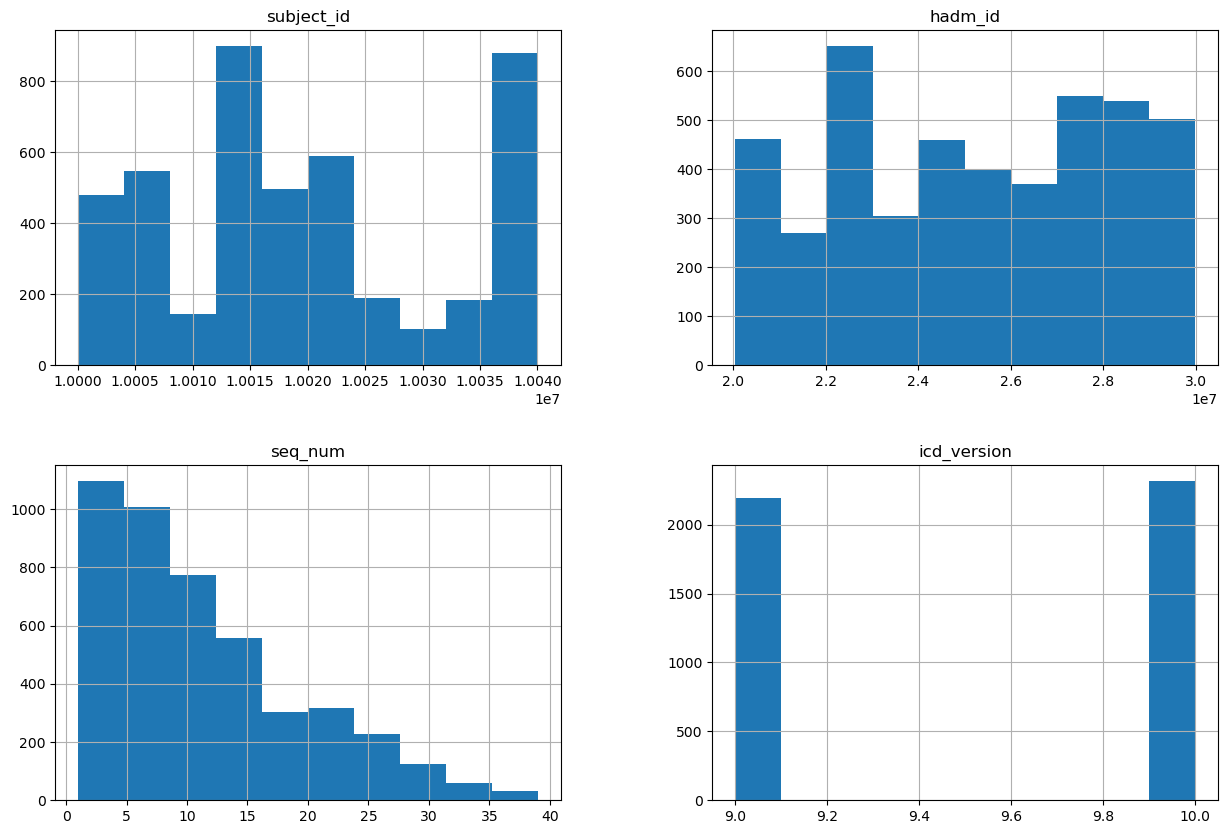

In [38]:
# EDA_diagnoses
# the distribution of continous variables

diagnoses.hist(figsize=(15,10))

plt.show()

In [39]:
diagnoses.seq_num.describe()

count    4506.000000
mean       11.163338
std         8.200563
min         1.000000
25%         5.000000
50%         9.000000
75%        16.000000
max        39.000000
Name: seq_num, dtype: float64

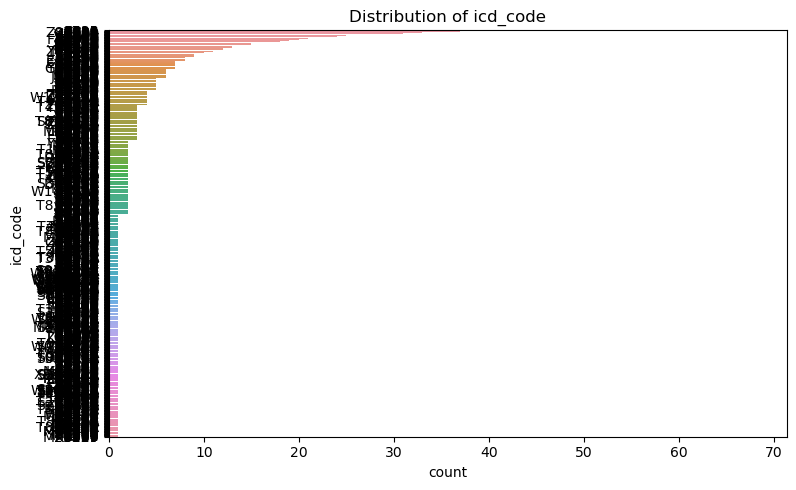

In [40]:
cat_cols = diagnoses.select_dtypes(include=['object', 'category']).columns

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    #  sorted in order of frequency
    sns.countplot(data=diagnoses, y=col, order=diagnoses[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

In [42]:
# to check what is the high frequency
d_icd = pd.read_csv('./data/hosp/d_icd_diagnoses.csv.gz')

# top_dianoses
top_diagnoses = diagnoses['icd_code'].value_counts().reset_index()
top_diagnoses.columns = ['icd_code', 'count']

# check the title
top_10_summary = pd.merge(top_diagnoses.head(10), 
                          d_icd[['icd_code', 'icd_version', 'long_title']], 
                          on='icd_code', 
                          how='left')

In [43]:
top_10_summary

,icd_code,count,icd_version,long_title
0,4019,68,9,Unspecified essential hypertension
1,E785,57,10,"Hyperlipidemia, unspecified"
2,2724,55,9,Other and unspecified hyperlipidemia
3,E039,47,10,"Hypothyroidism, unspecified"
4,Z794,37,10,Long term (current) use of insulin
5,Z87891,35,10,Personal history of nicotine dependence
6,42731,34,9,Atrial fibrillation
7,25000,33,9,Diabetes mellitus without mention of complicat...
8,I2510,33,10,Atherosclerotic heart disease of native corona...
9,I10,32,10,Essential (primary) hypertension


In [44]:
hf_diagnoses = diagnoses[
     ((diagnoses['icd_version'] == 9) & (diagnoses['icd_code'].str.startswith('428'))) |
     ((diagnoses['icd_version'] == 10) & (diagnoses['icd_code'].str.startswith('I50')))
 ].copy()
print(f"number of HF: {len(hf_diagnoses)}")

number of HF: 79


In [45]:
# Number of cases before deduplication
raw_count = len(hf_diagnoses)
print(f"number of diagnoses without duplication: {raw_count}")
# Number of cases after deduplication(number of admissions)
unique_admissions = hf_diagnoses['hadm_id'].drop_duplicates()
unique_count = len(unique_admissions)
print(f"Number of admissions after deduplication: {unique_count}")

number of diagnoses without duplication: 79
Number of admissions after deduplication: 61


# EDA for labevents

In [47]:
labevents = pd.read_csv('./data/hosp/labevents.csv.gz')
labevents.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,172061,10014354,29600294.0,1808066,51277,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,15.4,15.40,%,10.5,15.5,NaN,ROUTINE,NaN
1,172062,10014354,29600294.0,1808066,51279,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,3.35,3.35,m/uL,4.6,6.1,abnormal,ROUTINE,NaN
2,172068,10014354,29600294.0,1808066,52172,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,49.7,49.70,fL,35.1,46.3,abnormal,ROUTINE,NaN
3,172063,10014354,29600294.0,1808066,51301,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,20.3,20.30,K/uL,4.0,10.0,abnormal,ROUTINE,NaN
4,172050,10014354,29600294.0,1808066,51249,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,31.1,31.10,g/dL,32.0,37.0,abnormal,ROUTINE,NaN


In [48]:
labevents.info()
labevents.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107727 entries, 0 to 107726
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   labevent_id        107727 non-null  int64  
 1   subject_id         107727 non-null  int64  
 2   hadm_id            79307 non-null   float64
 3   specimen_id        107727 non-null  int64  
 4   itemid             107727 non-null  int64  
 5   order_provider_id  16830 non-null   object 
 6   charttime          107727 non-null  object 
 7   storetime          106735 non-null  object 
 8   value              98139 non-null   object 
 9   valuenum           95246 non-null   float64
 10  valueuom           91524 non-null   object 
 11  ref_range_lower    88999 non-null   float64
 12  ref_range_upper    88999 non-null   float64
 13  flag               40275 non-null   object 
 14  priority           98398 non-null   object 
 15  comments           18454 non-null   object 
dtypes:

labevent_id          107727
subject_id              100
hadm_id                 252
specimen_id           11122
itemid                  498
order_provider_id       151
charttime              5864
storetime             14573
value                  3107
valuenum               3032
valueuom                 49
ref_range_lower          95
ref_range_upper         134
flag                      1
priority                  2
comments                736
dtype: int64

In [49]:
labevents.isna().sum()

labevent_id              0
subject_id               0
hadm_id              28420
specimen_id              0
itemid                   0
order_provider_id    90897
charttime                0
storetime              992
value                 9588
valuenum             12481
valueuom             16203
ref_range_lower      18728
ref_range_upper      18728
flag                 67452
priority              9329
comments             89273
dtype: int64

In [50]:
# what values in NaN and their counts
nan_value_counts = labevents[labevents['valuenum'].isnull()]['value'].value_counts()

# top 20
print(nan_value_counts.head(20))

value
ART.                                                  734
NEG                                                   316
NONE                                                  243
VEN.                                                  227
INTUBATED.                                            209
___                                                   143
HOLD.  DISCARD GREATER THAN 4 HOURS OLD.              137
HOLD.  DISCARD GREATER THAN 24 HRS OLD.               114
DONE                                                   90
HOLD.                                                  83
NOT INTUBATED.                                         65
CONTROLLED.                                            59
HOLD.  SPECIMEN TO BE HELD 48 HOURS AND DISCARDED.     53
MIX.                                                   46
CENTRAL VENOUS.                                        26
SPONTANEOUS.                                           23
POS                                                    20
Yellow  

# EDA for chartevents

In [52]:
chartevents = pd.read_csv('./data/icu/chartevents.csv.gz')
chartevents.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0


In [53]:
chartevents.info()
chartevents.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668862 entries, 0 to 668861
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   subject_id    668862 non-null  int64  
 1   hadm_id       668862 non-null  int64  
 2   stay_id       668862 non-null  int64  
 3   caregiver_id  644622 non-null  float64
 4   charttime     668862 non-null  object 
 5   storetime     667703 non-null  object 
 6   itemid        668862 non-null  int64  
 7   value         648132 non-null  object 
 8   valuenum      257474 non-null  float64
 9   valueuom      162571 non-null  object 
 10  warning       667703 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 56.1+ MB


subject_id        100
hadm_id           128
stay_id           140
caregiver_id      692
charttime       36303
storetime       53751
itemid           1318
value            4241
valuenum         2458
valueuom           43
warning             2
dtype: int64

In [54]:
chartevents.isna().sum()

subject_id           0
hadm_id              0
stay_id              0
caregiver_id     24240
charttime            0
storetime         1159
itemid               0
value            20730
valuenum        411388
valueuom        506291
warning           1159
dtype: int64

# EDA for icustays

In [55]:
icustays = pd.read_csv('./data/icu/icustays.csv.gz')
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [56]:
icustays.info()
icustays.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      140 non-null    int64  
 1   hadm_id         140 non-null    int64  
 2   stay_id         140 non-null    int64  
 3   first_careunit  140 non-null    object 
 4   last_careunit   140 non-null    object 
 5   intime          140 non-null    object 
 6   outtime         140 non-null    object 
 7   los             140 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 8.9+ KB


subject_id        100
hadm_id           128
stay_id           140
first_careunit      9
last_careunit       9
intime            140
outtime           140
los               140
dtype: int64

In [57]:
icustays.isna().sum()

subject_id        0
hadm_id           0
stay_id           0
first_careunit    0
last_careunit     0
intime            0
outtime           0
los               0
dtype: int64

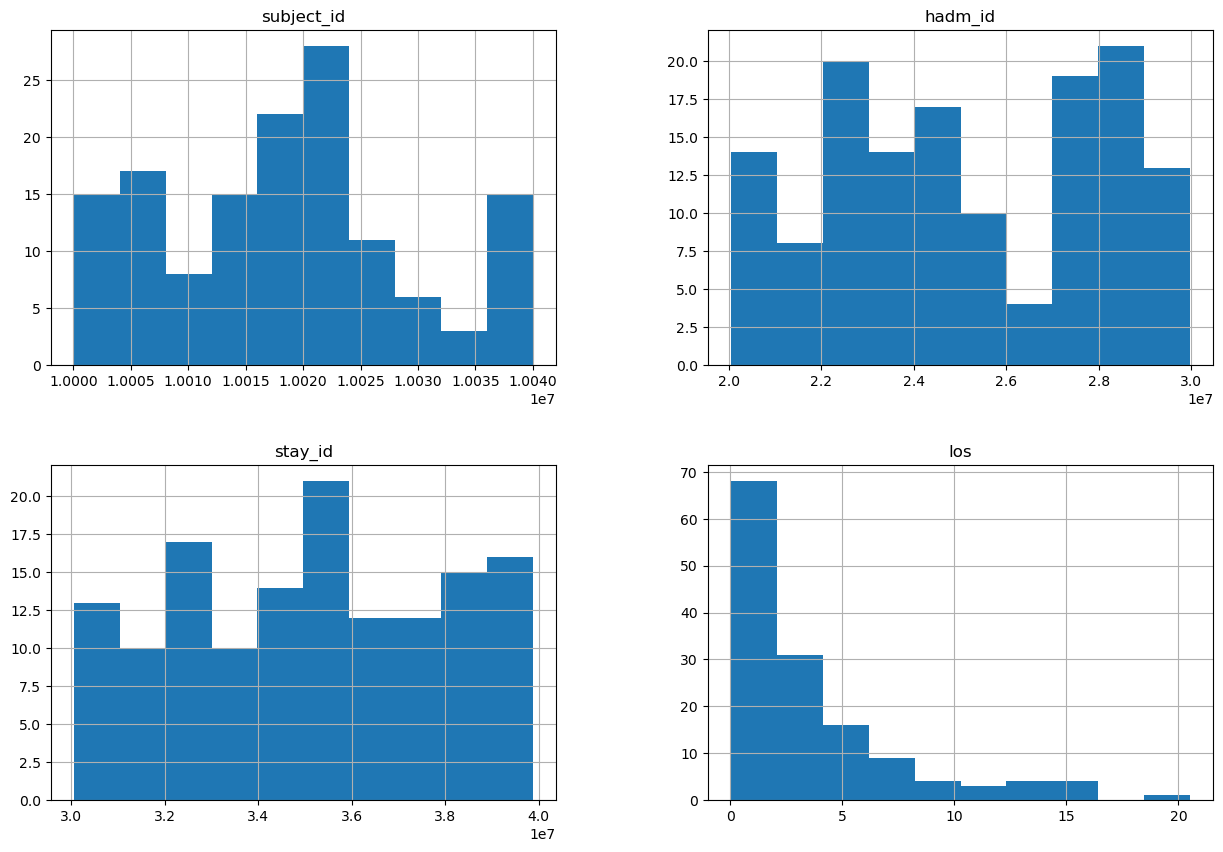

In [58]:
# EDA_icustays
# the distribution of continous variables

icustays.hist(figsize=(15,10))

plt.show()

In [59]:
icustays.los.describe()

count    140.000000
mean       3.679379
std        3.896354
min        0.023727
25%        1.170663
50%        2.155093
75%        4.907749
max       20.528681
Name: los, dtype: float64

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


([<matplotlib.axis.XTick at 0x168e61fa810>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20')])

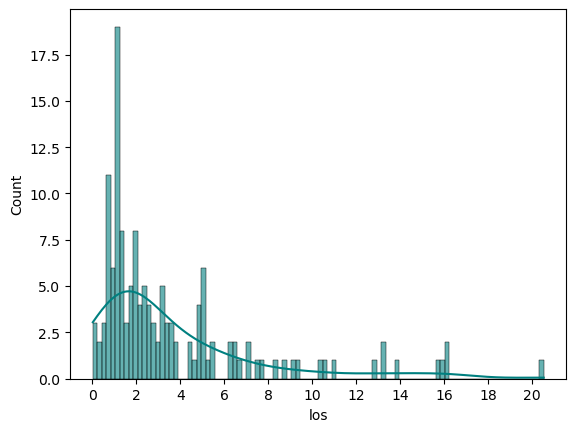

In [60]:
sns.histplot(data=icustays, x='los', bins=100, kde=True, color='teal', alpha=0.6)
plt.xticks(np.arange(0, 21, 2))

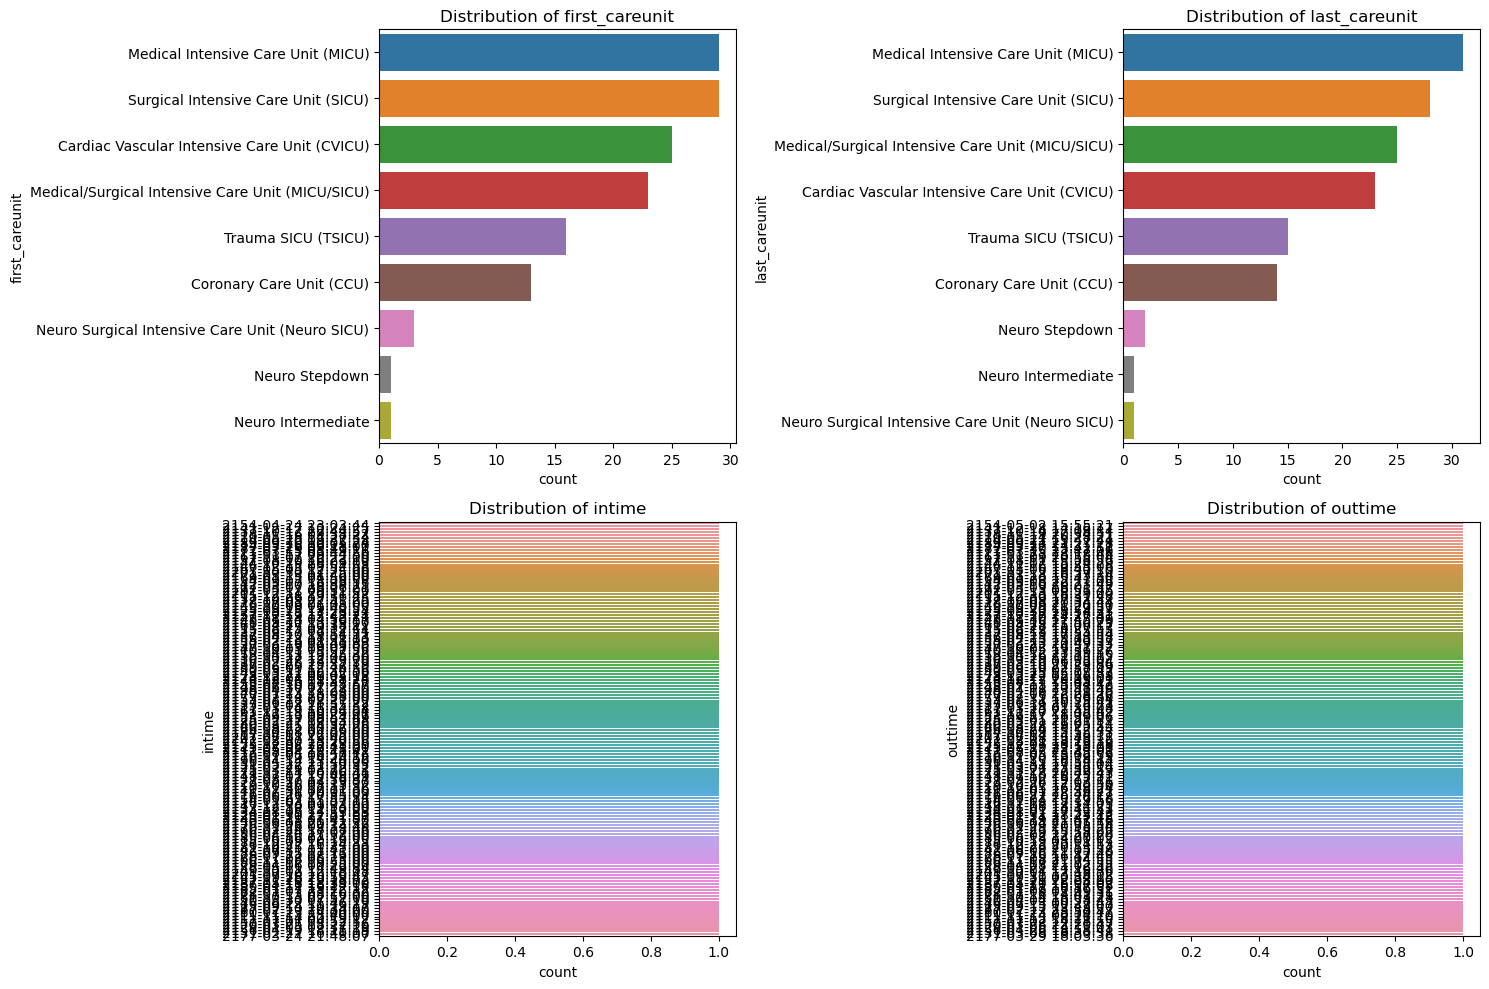

In [61]:
cat_cols = icustays.select_dtypes(include=['object', 'category']).columns

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    #  sorted in order of frequency
    sns.countplot(data=icustays, y=col, order=icustays[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

In [62]:
for col in cat_cols :
    print(f"--- {col} ---")
    print(icustays[col].value_counts(normalize=True) * 100) # as a percent
    print("\n")

--- first_careunit ---
first_careunit
Medical Intensive Care Unit (MICU)                  20.714286
Surgical Intensive Care Unit (SICU)                 20.714286
Cardiac Vascular Intensive Care Unit (CVICU)        17.857143
Medical/Surgical Intensive Care Unit (MICU/SICU)    16.428571
Trauma SICU (TSICU)                                 11.428571
Coronary Care Unit (CCU)                             9.285714
Neuro Surgical Intensive Care Unit (Neuro SICU)      2.142857
Neuro Stepdown                                       0.714286
Neuro Intermediate                                   0.714286
Name: proportion, dtype: float64


--- last_careunit ---
last_careunit
Medical Intensive Care Unit (MICU)                  22.142857
Surgical Intensive Care Unit (SICU)                 20.000000
Medical/Surgical Intensive Care Unit (MICU/SICU)    17.857143
Cardiac Vascular Intensive Care Unit (CVICU)        16.428571
Trauma SICU (TSICU)                                 10.714286
Coronary Care Unit (CCU

#  patients + admissions_ver1 = df

In [63]:
df = admissions_ver1.merge(patients[['subject_id', 'gender', 'anchor_age', 'anchor_year', 'dod']], on='subject_id', how='left')
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,admittime_dt,dischtime_dt,deathtime_dt,edregtime_dt,edouttime_dt,gender,anchor_age,anchor_year,dod
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,0,2196-02-24 14:38:00,2196-03-04 14:02:00,NaT,2196-02-24 12:15:00,2196-02-24 17:07:00,M,47,2196,NaN
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,...,0,2153-09-17 17:08:00,2153-09-25 13:20:00,NaT,NaT,NaT,M,58,2153,NaN
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,0,2134-08-18 02:02:00,2134-08-23 19:35:00,NaT,2134-08-17 16:24:00,2134-08-18 03:15:00,M,79,2133,2134-10-28
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,...,1,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,NaT,NaT,M,52,2111,2111-11-15
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,...,0,2113-08-04 18:46:00,2113-08-06 20:57:00,NaT,NaT,NaT,F,82,2113,NaN


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            275 non-null    int64         
 1   hadm_id               275 non-null    int64         
 2   admittime             275 non-null    object        
 3   dischtime             275 non-null    object        
 4   deathtime             15 non-null     object        
 5   admission_type        275 non-null    object        
 6   admit_provider_id     275 non-null    object        
 7   admission_location    275 non-null    object        
 8   discharge_location    233 non-null    object        
 9   insurance             275 non-null    object        
 10  language              275 non-null    object        
 11  marital_status        263 non-null    object        
 12  race                  275 non-null    object        
 13  edregtime           

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


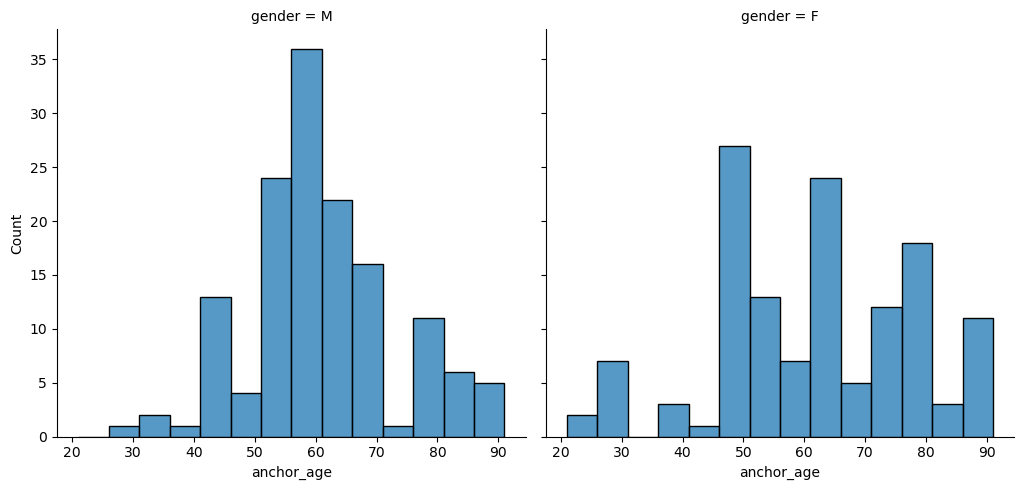

In [66]:
sns.displot(data=df, x='anchor_age', col='gender', col_wrap=5)

plt.show()

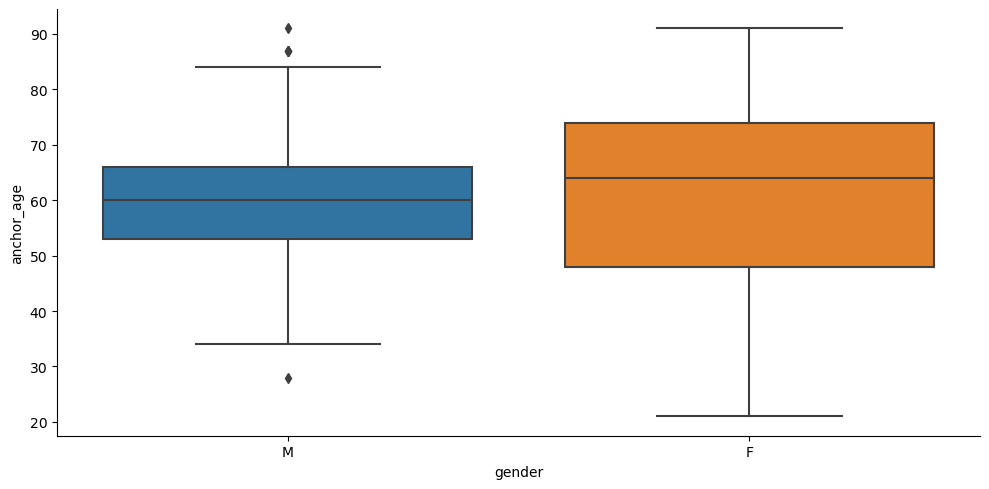

In [67]:
sns.catplot(data=df, x='gender', y='anchor_age', kind='box', aspect=2)

plt.show()

In [68]:
gender_age_stats = df.groupby('gender')['anchor_age'].describe()

print(gender_age_stats)

        count       mean        std   min   25%   50%   75%   max
gender                                                           
F       133.0  61.436090  16.704814  21.0  48.0  64.0  74.0  91.0
M       142.0  60.676056  11.987907  28.0  53.0  60.0  66.0  91.0


c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


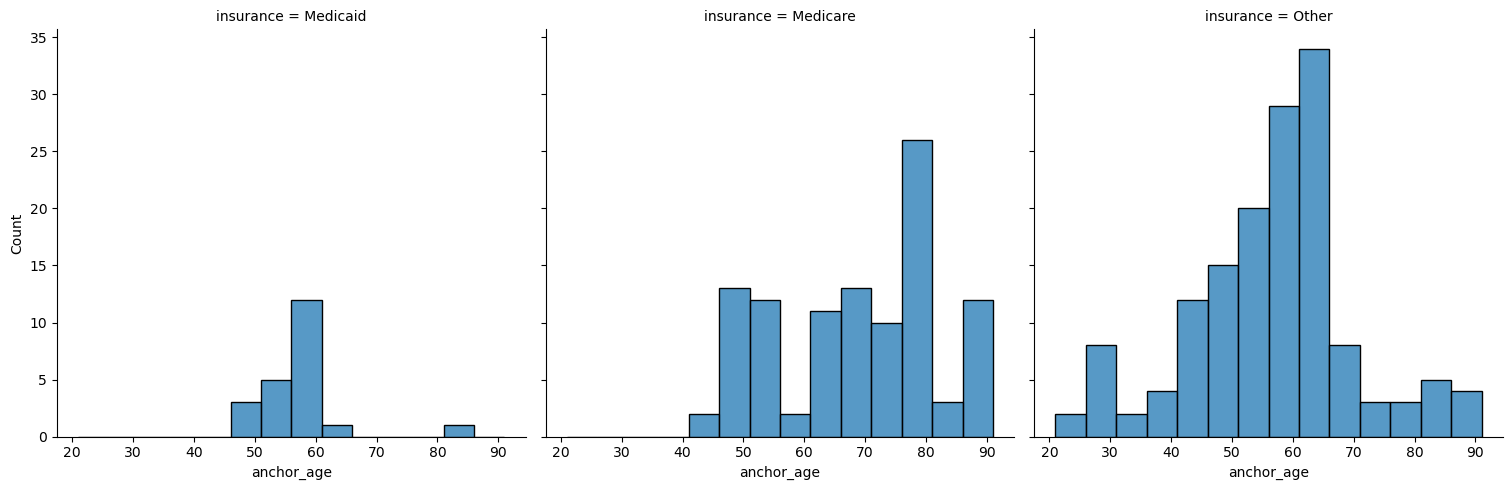

In [69]:
sns.displot(data=df, x='anchor_age', col='insurance', col_wrap=5)

plt.show()

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


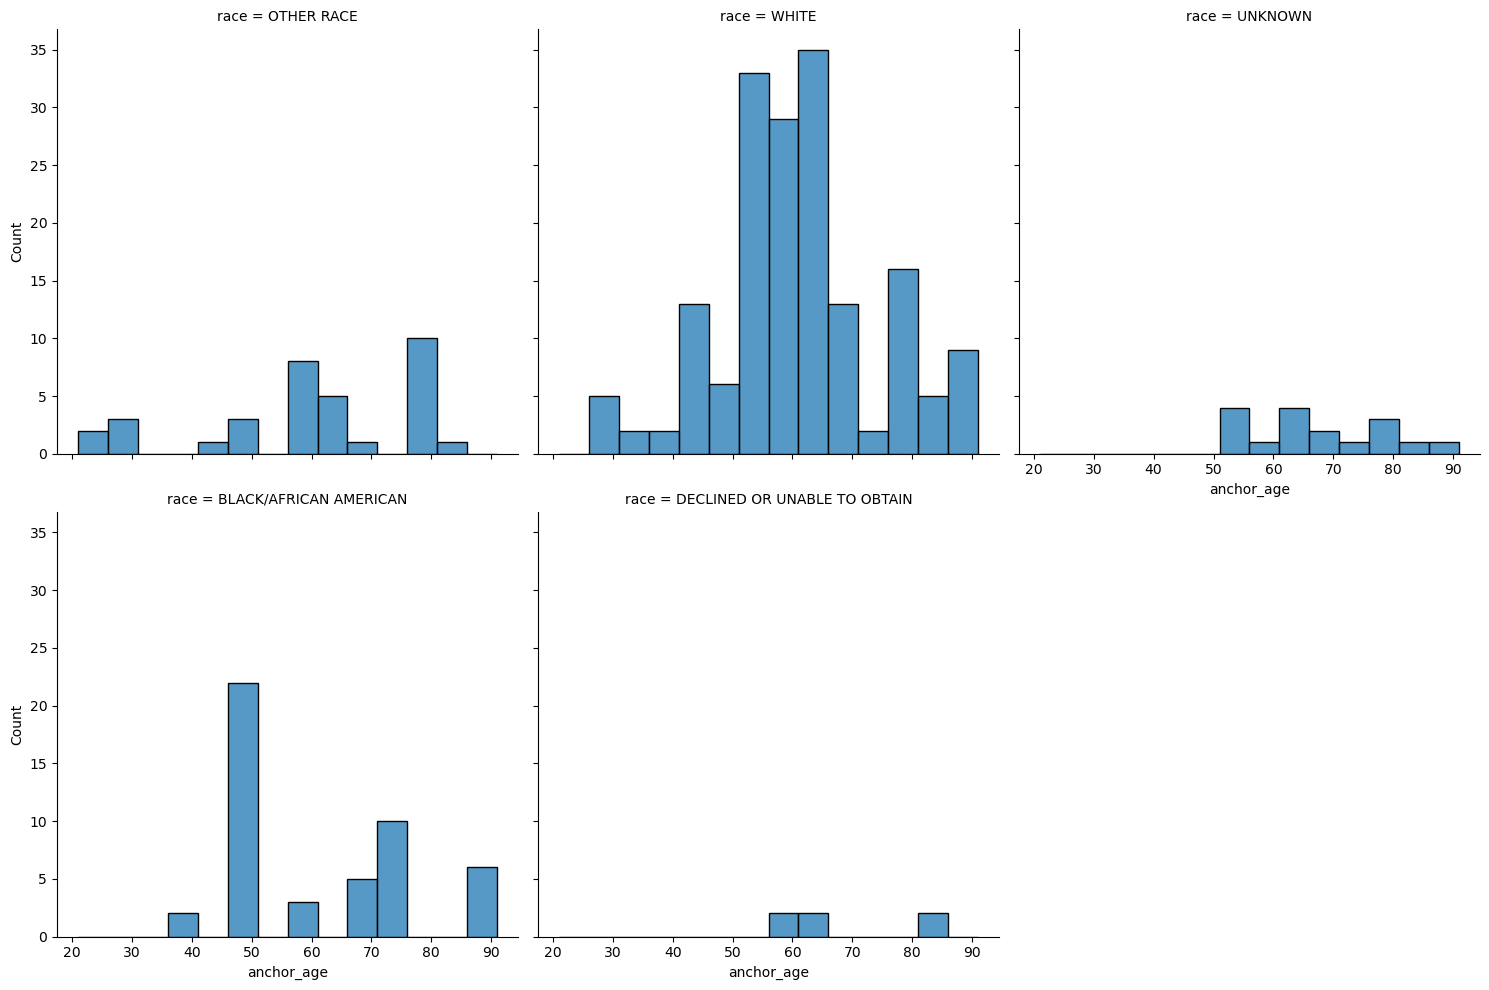

In [70]:
sns.displot(data=df, x='anchor_age', col='race', col_wrap=3)

plt.show()

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


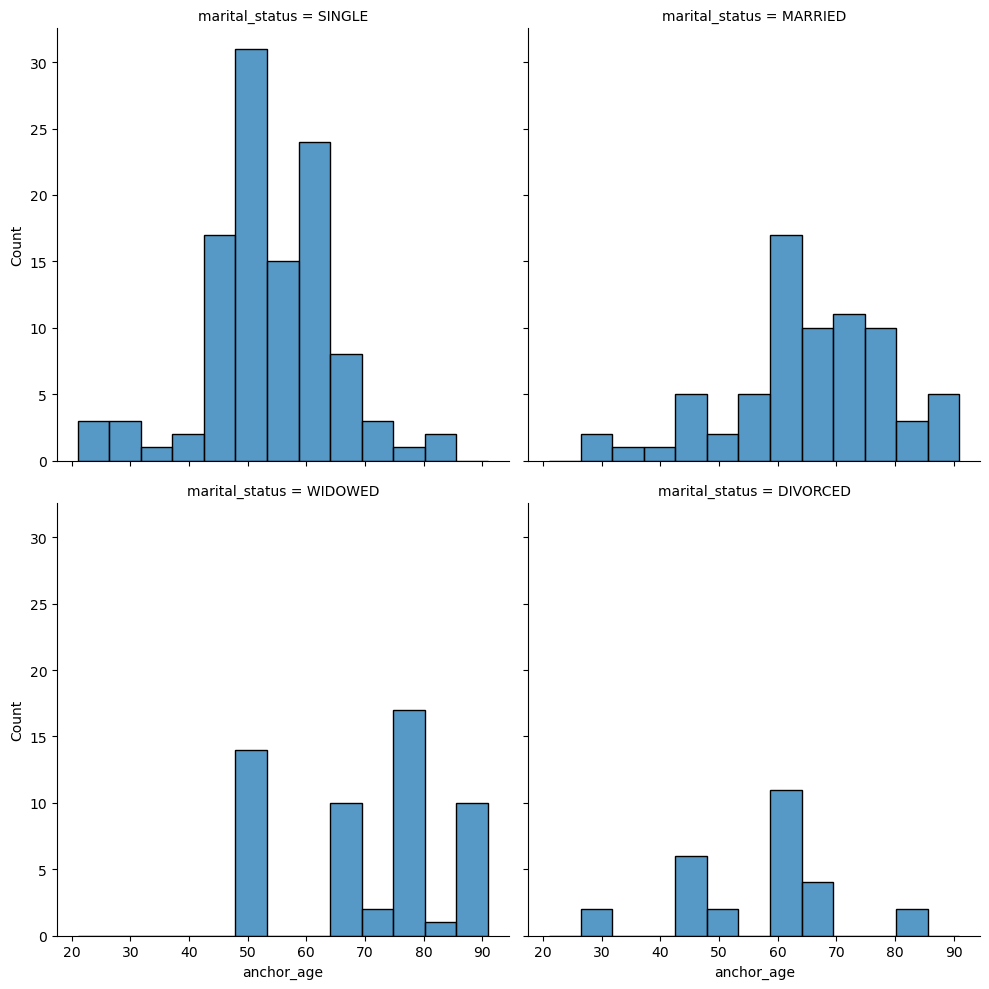

In [71]:
sns.displot(data=df, x='anchor_age', col='marital_status', col_wrap=2)

plt.show()

admission_type  DIRECT EMER.  EU OBSERVATION  EW EMER.  OBSERVATION ADMIT  \
gender                                                                      
F                          4              17        55                 22   
M                         11              13        49                 23   

admission_type  OTHERS  SURGICAL SAME DAY ADMISSION  URGENT  
gender                                                       
F                   12                            7      16  
M                   13                           11      22  


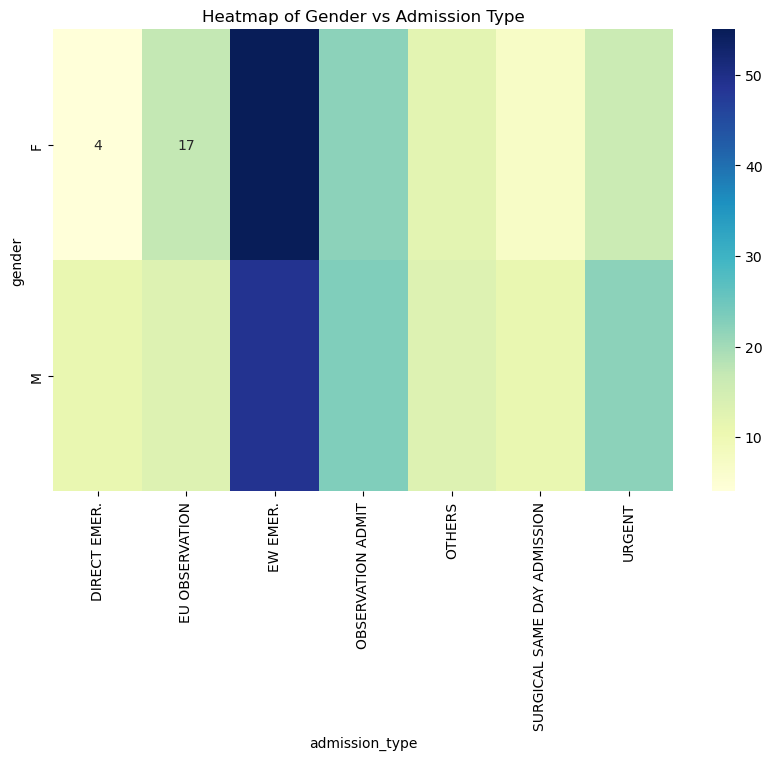

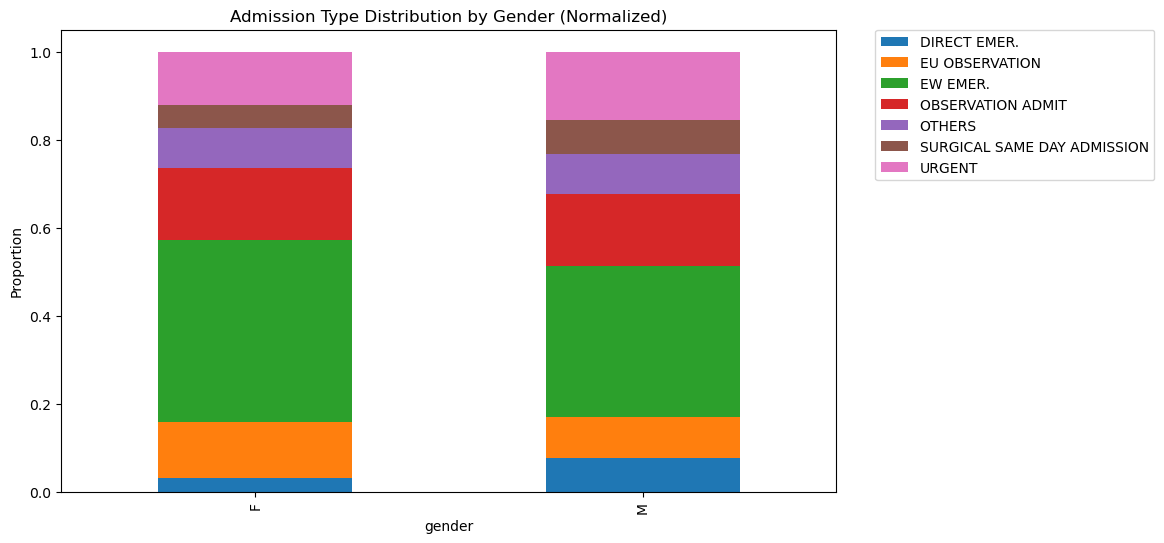

In [72]:
#crosstab
crosstab = pd.crosstab(df['gender'], df['admission_type'])

print(crosstab)

# heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Gender vs Admission Type')
plt.show()

crosstab_norm = pd.crosstab(df['gender'], df['admission_type'], normalize='index')

crosstab_norm.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Admission Type Distribution by Gender (Normalized)')
plt.ylabel('Proportion')
plt.show()

race    BLACK/AFRICAN AMERICAN  DECLINED OR UNABLE TO OBTAIN  OTHER RACE  \
gender                                                                     
F                           46                             4          18   
M                            2                             2          16   

race    UNKNOWN  WHITE  
gender                  
F             5     60  
M            12    110  


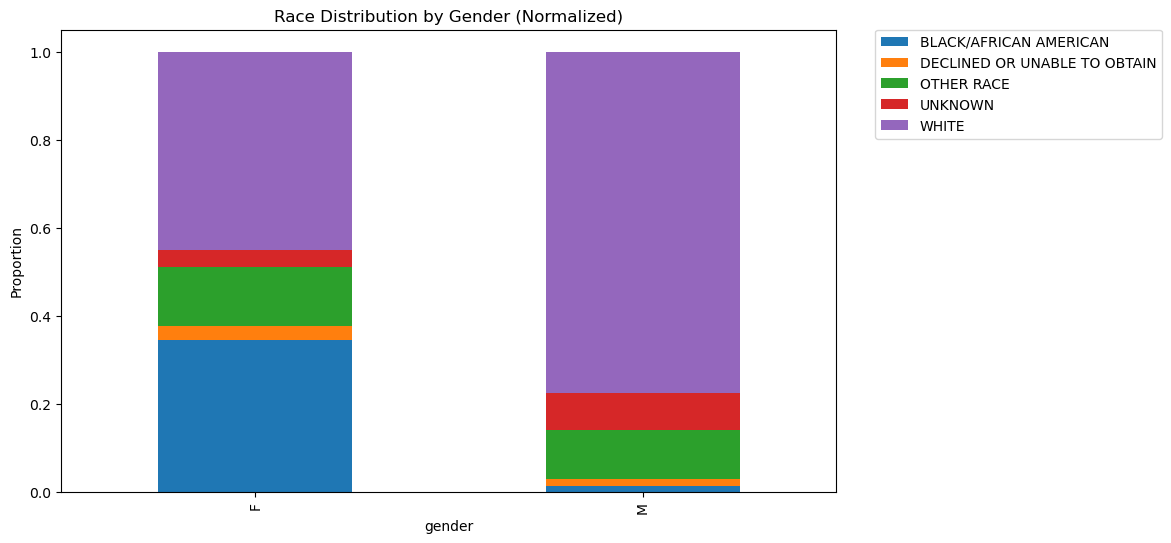

In [73]:
#crosstab
crosstab = pd.crosstab(df['gender'], df['race'])

print(crosstab)

crosstab_norm = pd.crosstab(df['gender'], df['race'], normalize='index')

crosstab_norm.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Race Distribution by Gender (Normalized)')
plt.ylabel('Proportion')
plt.show()

<Axes: xlabel='gender', ylabel='count'>

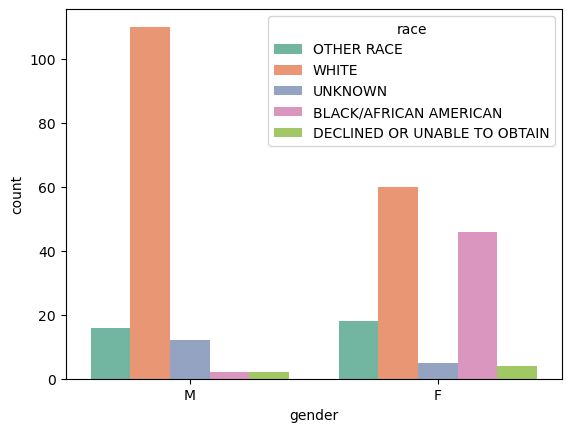

In [74]:
sns.countplot(data=df, x='gender', hue='race', palette='Set2')

race       BLACK/AFRICAN AMERICAN  DECLINED OR UNABLE TO OBTAIN  OTHER RACE  \
insurance                                                                     
Medicaid                        3                             2          12   
Medicare                       31                             0          12   
Other                          14                             4          10   

race       UNKNOWN  WHITE  
insurance                  
Medicaid         2      3  
Medicare         7     54  
Other            8    113  


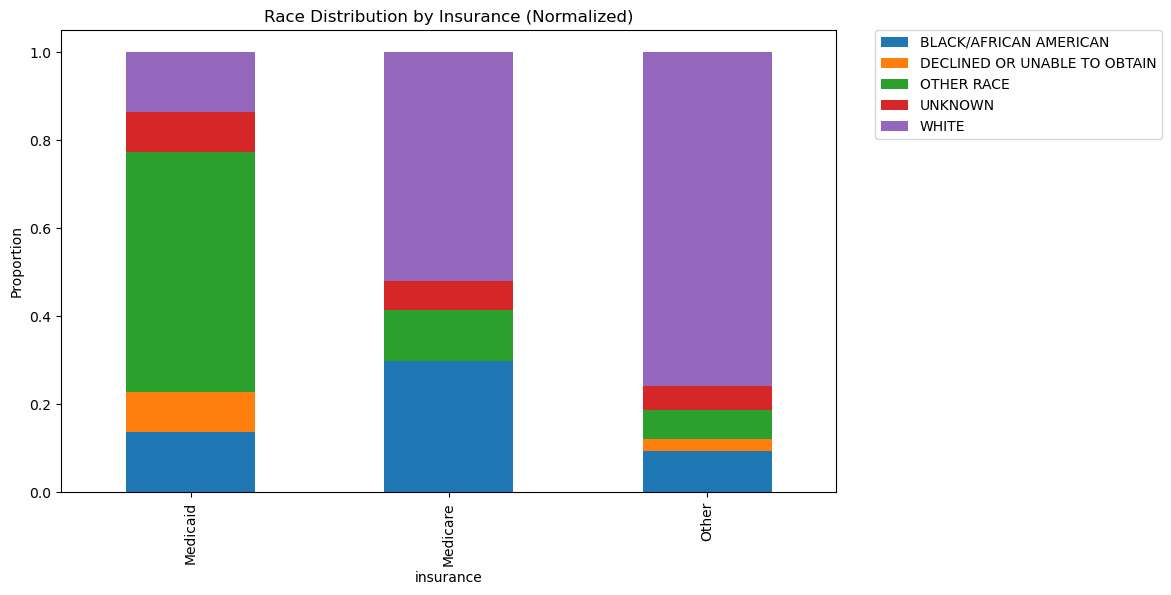

In [75]:
crosstab = pd.crosstab(df['insurance'], df['race'])

print(crosstab)

crosstab_norm = pd.crosstab(df['insurance'], df['race'], normalize='index')

crosstab_norm.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Race Distribution by Insurance (Normalized)')
plt.ylabel('Proportion')
plt.show()

<Axes: xlabel='insurance', ylabel='count'>

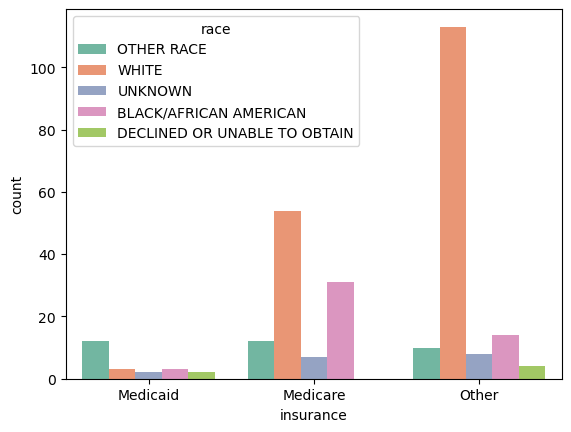

In [76]:
sns.countplot(data=df, x='insurance', hue='race', palette='Set2')

# df + icustays

In [77]:
# sum-up all the los in icustays by hadm_id
# reset_index()
icu_los_sum = icustays.groupby('hadm_id')['los'].sum().reset_index()

# column name
icu_los_sum.rename(columns={'los': 'total_icu_los'}, inplace=True)

In [78]:
# merge: df + icustays
# how='left': df + only merge whom has their hadm_id in icustays
df_icu = pd.merge(df, icu_los_sum, on='hadm_id', how='left')
df_icu.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,admittime_dt,dischtime_dt,deathtime_dt,edregtime_dt,edouttime_dt,gender,anchor_age,anchor_year,dod,total_icu_los
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,2196-02-24 14:38:00,2196-03-04 14:02:00,NaT,2196-02-24 12:15:00,2196-02-24 17:07:00,M,47,2196,NaN,4.952106
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,...,2153-09-17 17:08:00,2153-09-25 13:20:00,NaT,NaT,NaT,M,58,2153,NaN,2.280752
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,2134-08-18 02:02:00,2134-08-23 19:35:00,NaT,2134-08-17 16:24:00,2134-08-18 03:15:00,M,79,2133,2134-10-28,NaN
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,...,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,NaT,NaT,M,52,2111,2111-11-15,1.775093
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,...,2113-08-04 18:46:00,2113-08-06 20:57:00,NaT,NaT,NaT,F,82,2113,NaN,1.206481


In [79]:
df_icu.info()
df_icu.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            275 non-null    int64         
 1   hadm_id               275 non-null    int64         
 2   admittime             275 non-null    object        
 3   dischtime             275 non-null    object        
 4   deathtime             15 non-null     object        
 5   admission_type        275 non-null    object        
 6   admit_provider_id     275 non-null    object        
 7   admission_location    275 non-null    object        
 8   discharge_location    233 non-null    object        
 9   insurance             275 non-null    object        
 10  language              275 non-null    object        
 11  marital_status        263 non-null    object        
 12  race                  275 non-null    object        
 13  edregtime           

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
admittime_dt              0
dischtime_dt              0
deathtime_dt            260
edregtime_dt             93
edouttime_dt             93
gender                    0
anchor_age                0
anchor_year               0
dod                     172
total_icu_los           147
dtype: int64

In [80]:
# set NaN who never go to icu. their los is NaN
# fillna(0)
df_icu['total_icu_los'] = df_icu['total_icu_los'].fillna(0)

print(df_icu[['hadm_id', 'total_icu_los']].head())

    hadm_id  total_icu_los
0  24181354       4.952106
1  25926192       2.280752
2  23983182       0.000000
3  22942076       1.775093
4  21606243       1.206481


In [81]:
df_icu.total_icu_los.describe()

count    275.000000
mean       1.873138
std        3.630192
min        0.000000
25%        0.000000
50%        0.000000
75%        1.992894
max       20.528681
Name: total_icu_los, dtype: float64

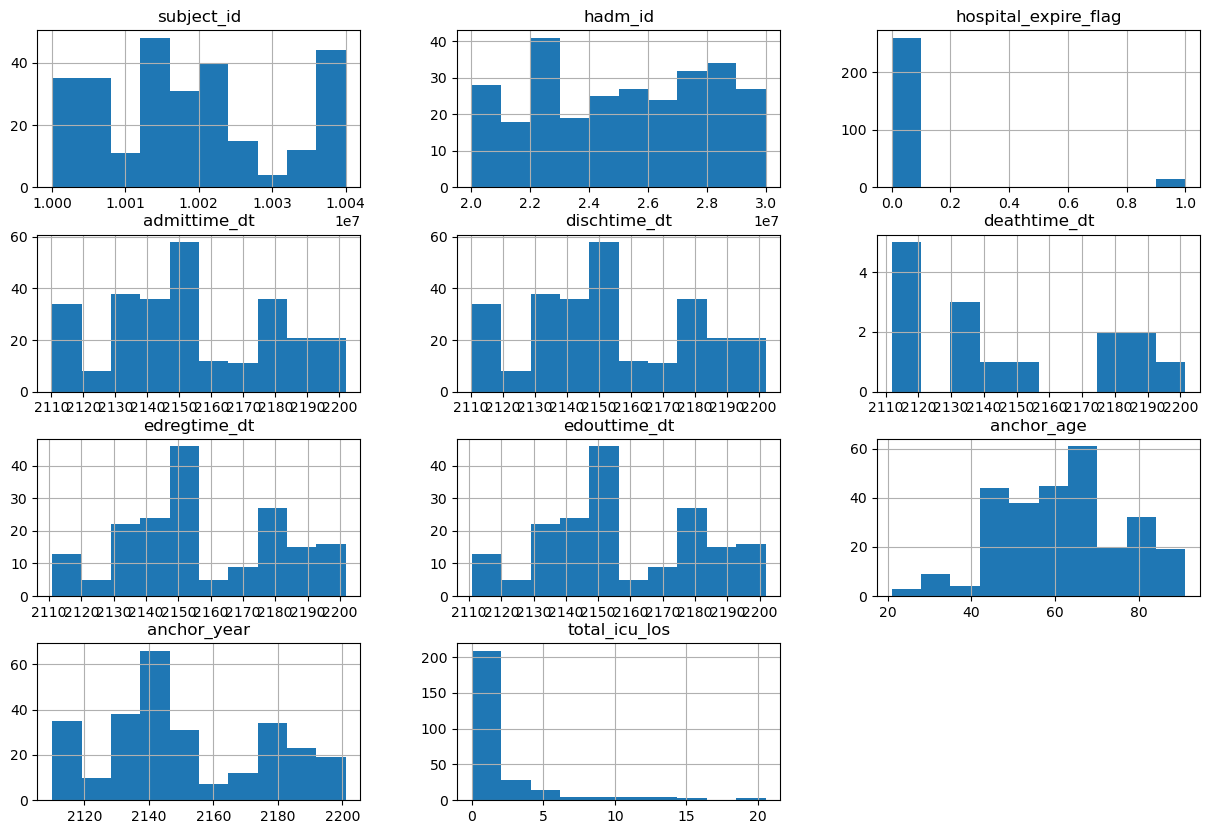

In [82]:
df_icu.hist(figsize=(15,10))

plt.show()

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


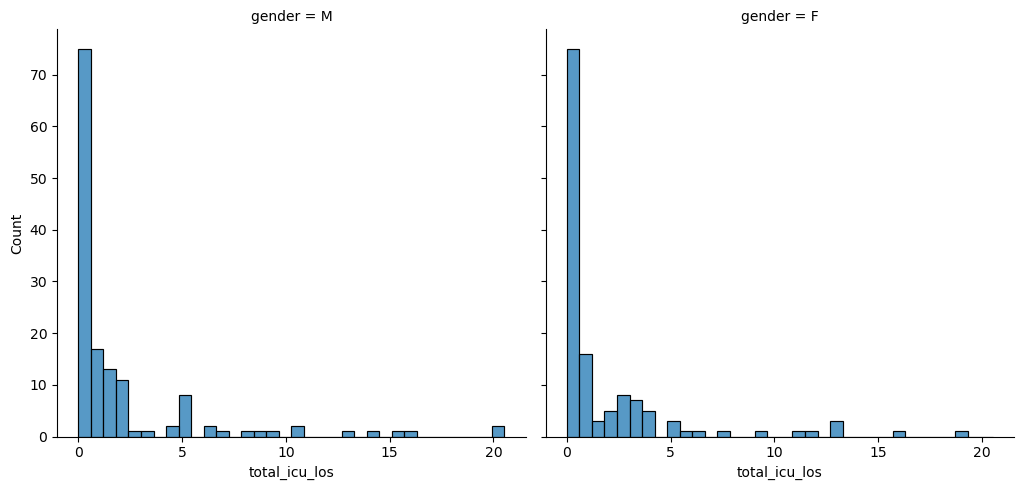

In [83]:
sns.displot(data=df_icu, x='total_icu_los', col='gender', col_wrap=5)
plt.show()

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


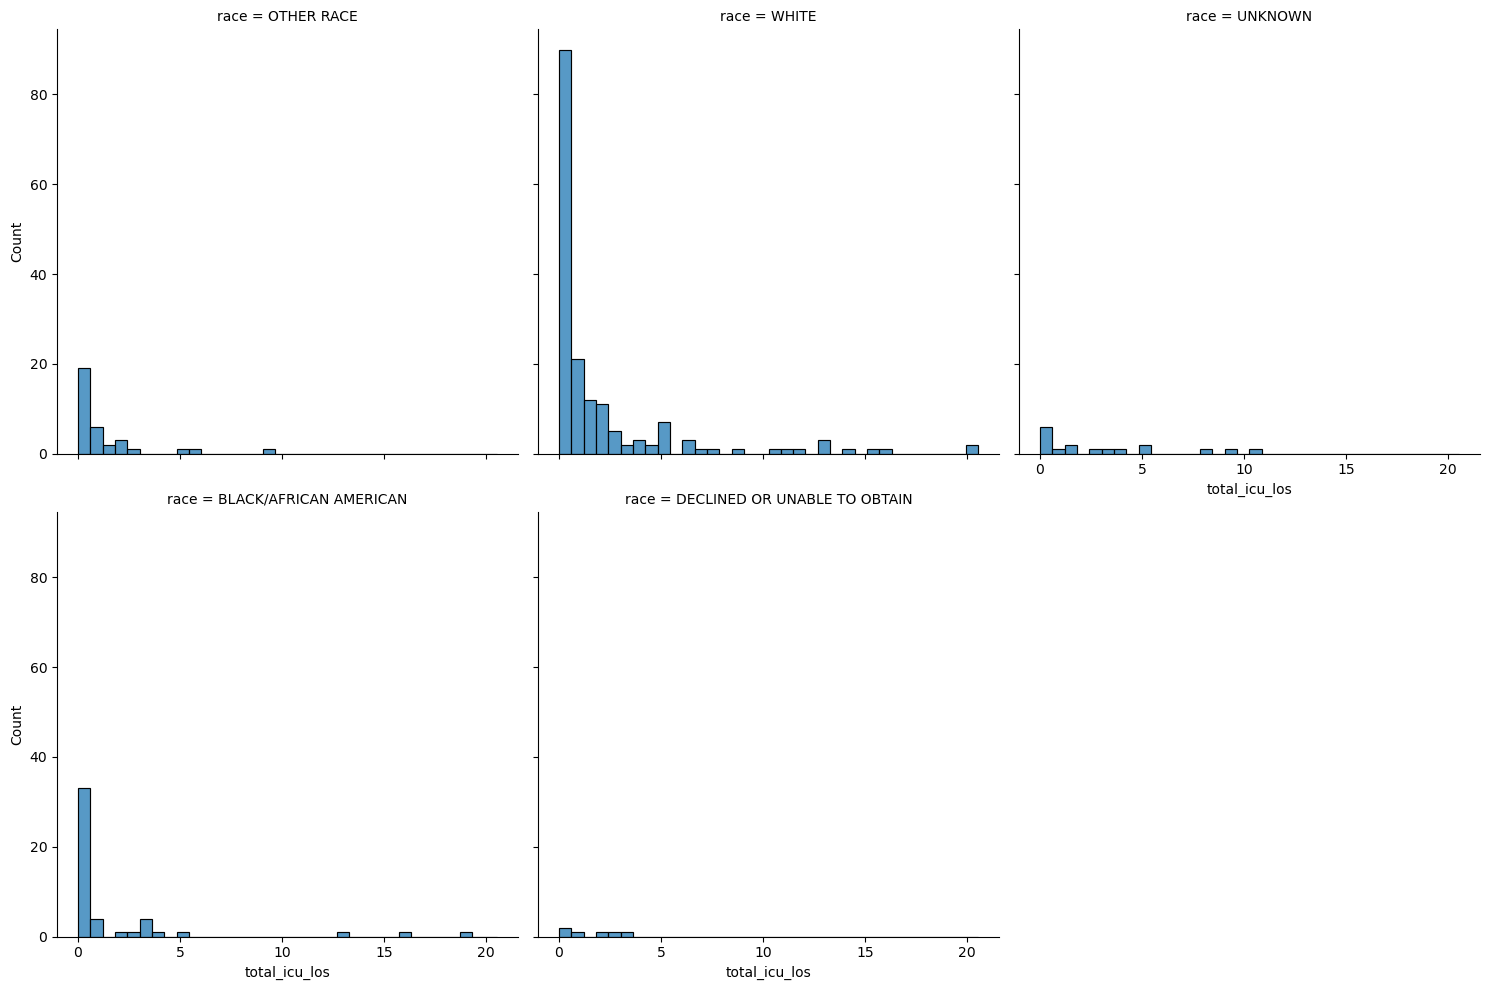

In [84]:
sns.displot(data=df_icu, x='total_icu_los', col='race', col_wrap=3)
plt.show()

c:\Users\joyer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


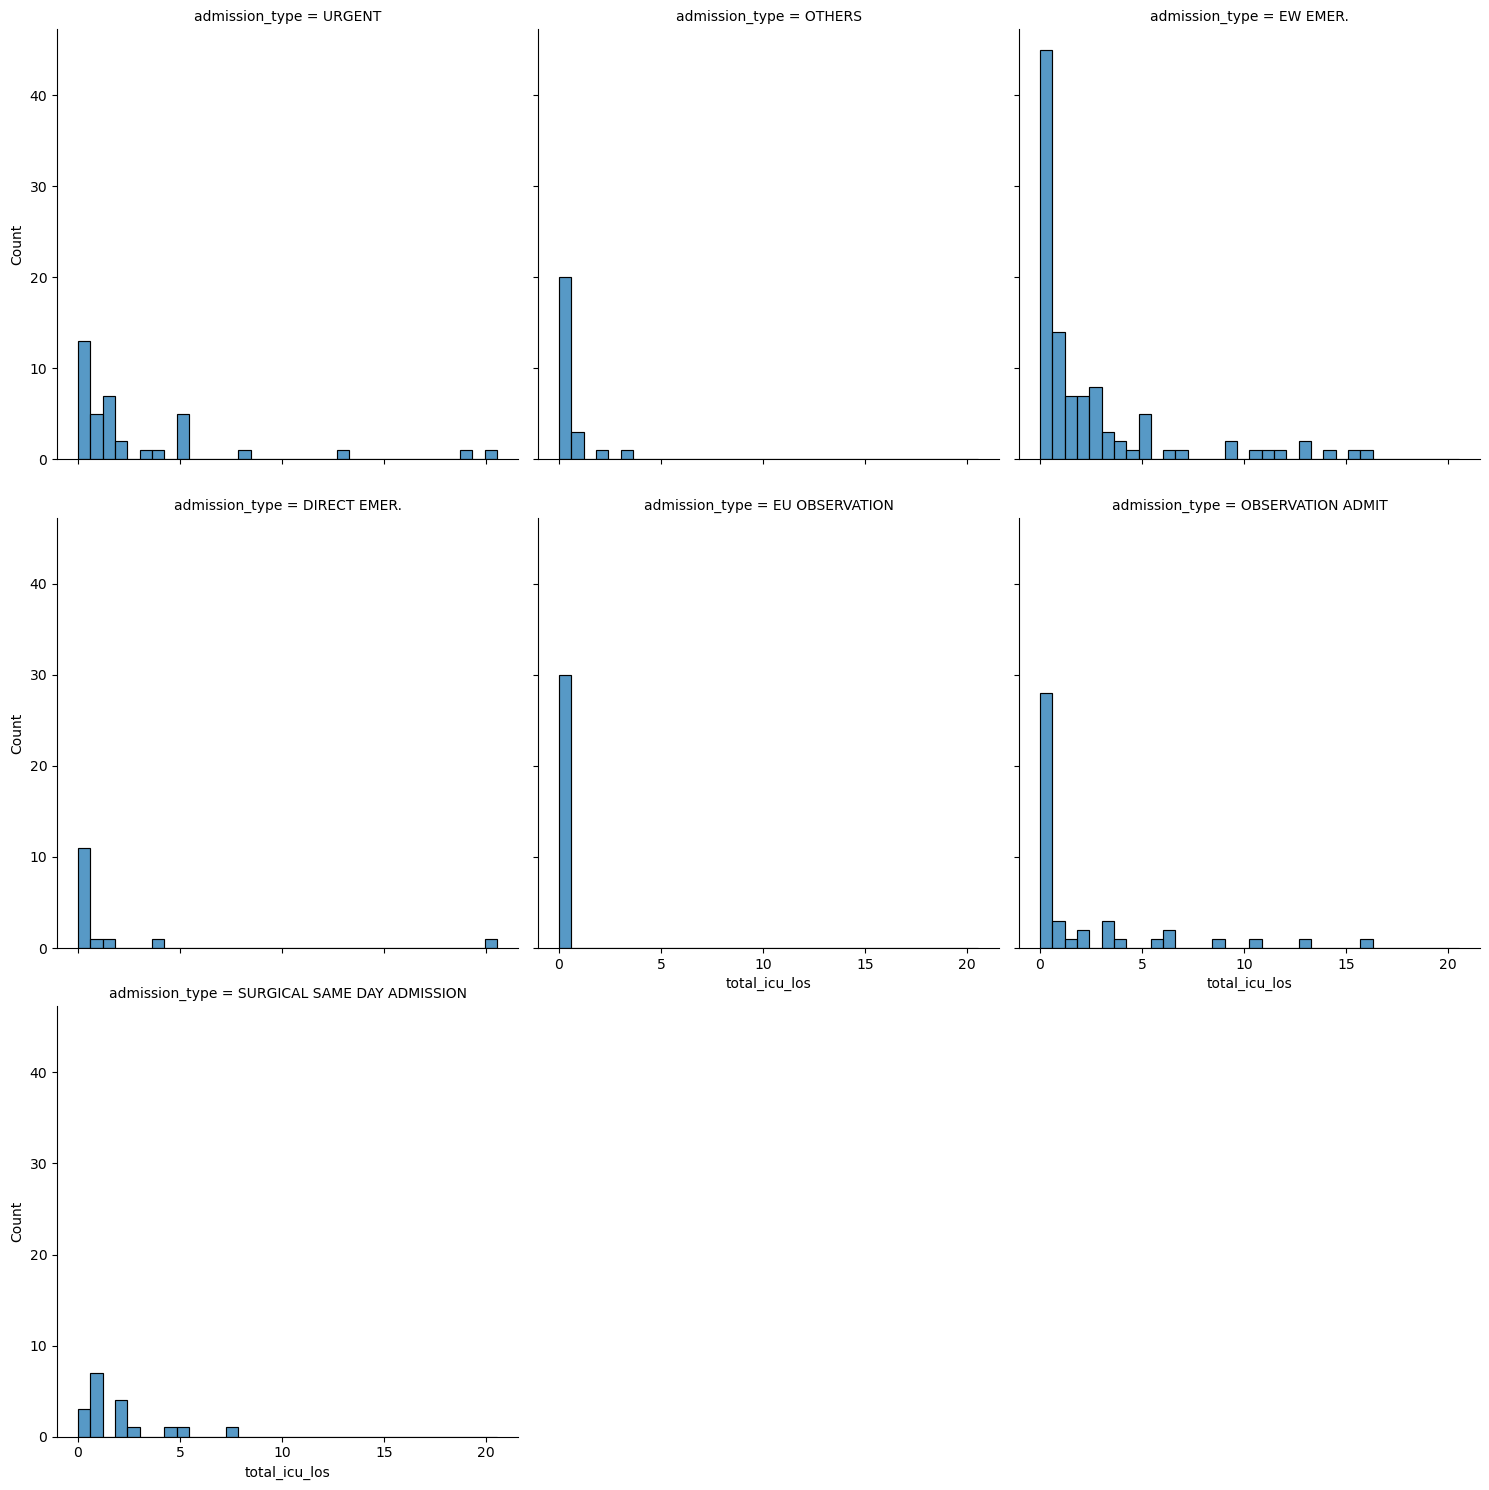

In [85]:
sns.displot(data=df_icu, x='total_icu_los', col='admission_type', col_wrap=3)
plt.show()

Text(0, 0.5, 'ICU Length of Stay (Days)')

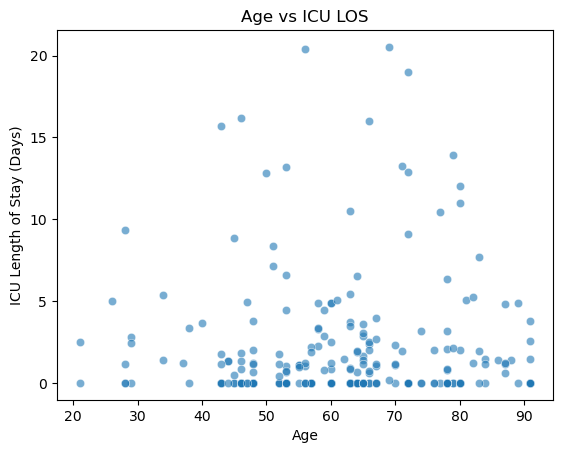

In [86]:
sns.scatterplot(data=df_icu, x='anchor_age', y='total_icu_los', alpha=0.6)

plt.title('Age vs ICU LOS')
plt.xlabel('Age')
plt.ylabel('ICU Length of Stay (Days)')

# consistency evaluation

In [87]:
# (1) all patients in Admissions present in the Patients table?
orphan_patients = admissions[~admissions['subject_id'].isin(patients['subject_id'])]
orphan_count_1 = len(orphan_patients)

# (2) all admissions in ICUstays present in the Admissions table?
orphan_admissions = icustays[~icustays['hadm_id'].isin(admissions['hadm_id'])]
orphan_count_2 = len(orphan_admissions)

print(f" - Orphan Patients (in Admissions but not in Patients): {orphan_count_1}")
print(f" - Orphan ICU Stays (in ICUstays but not in Admissions): {orphan_count_2}")

if orphan_count_1 == 0 and orphan_count_2 == 0:
    print(" Result: PASS (Referential Integrity)")
else:
    print(" Result: FAIL")
print("-" * 50)

 - Orphan Patients (in Admissions but not in Patients): 0
 - Orphan ICU Stays (in ICUstays but not in Admissions): 0
 Result: PASS (Referential Integrity)
--------------------------------------------------


In [88]:
# check if the discharge time is earlier than the admission time (Logical Error)
time_error_1 = admissions[admissions['dischtime'] < admissions['admittime']]
count_time_error_1 = len(time_error_1)

print(f" - Time Error (Discharge < Admit): {count_time_error_1} rows")


 - Time Error (Discharge < Admit): 0 rows


In [89]:
# Is the combination (subject_id + hadm_id) unique in the Admissions table?
duplicates = admissions.duplicated(subset=['subject_id', 'hadm_id'], keep=False)
dup_count = duplicates.sum()

print(f" - Duplicate Entries (Subject + Hadm ID): {dup_count}")

 - Duplicate Entries (Subject + Hadm ID): 0
